# Exploring Clinical Eye-Health Data: An Exploratory Statistical Analysis

## Introduction

This project explores clinical data from the PAPILA ophthalmology dataset using descriptive statistics, probability distributions, data visualization, covariance, and correlation analysis.

The goal is to understand the characteristics, variability, distributions, and relationships between selected clinical variables in the dataset.

This project focuses on exploratory data analysis and statistical concepts rather than predictive machine learning.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [8]:
os.listdir()

['.ipynb_checkpoints',
 'Learning.ipynb',
 'PAPILA_Statistical_Analysis.ipynb',
 'patient_data_od.xlsx',
 'patient_data_os.xlsx']

In [10]:
od = pd.read_excel("patient_data_od.xlsx")

## Dataset Overview

The dataset contains clinical measurements and demographic information for patients in the PAPILA ophthalmology dataset.

The analysis in this project focuses on the right-eye (OD) clinical data.

In [41]:
od.shape

(246, 13)

In [42]:
od.head()

,ID,Age,Gender,Diagnosis,Refractive_Defect,Unnamed: 5,Unnamed: 6,Phakic/Pseudophakic,IOP,Unnamed: 9,Pachymetry,Axial_Length,VF_MD
0,NaN,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
1,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#002,47,0,2,0.75,-1.75,90,0,21,NaN,586,23.64,-0.07
3,#004,58,1,1,1.5,-1.75,85,0,NaN,19,501,23.06,-3.26
4,#005,89,1,1,-0.75,-1.25,101,1,13,14,565,23.81,-14.98


In [43]:
od.columns

Index(['ID', 'Age', 'Gender', 'Diagnosis', 'Refractive_Defect', 'Unnamed: 5',
       'Unnamed: 6', 'Phakic/Pseudophakic', 'IOP', 'Unnamed: 9', 'Pachymetry',
       'Axial_Length', 'VF_MD'],
      dtype='object')

## Data Cleaning

In [64]:
clean_od = od.copy()

In [65]:
clean_od = clean_od.rename(columns={
    'Unnamed: 0': 'ID',
    'Refractive_Defect': 'dioptre_1',
    'Unnamed: 5': 'dioptre_2',
    'Unnamed: 6': 'astigmatism',
    'IOP': 'Pneumatic',
    'Unnamed: 9': 'Perkins'
})

In [66]:
clean_od = clean_od.iloc[2:]

In [67]:
clean_od.columns

Index(['ID', 'Age', 'Gender', 'Diagnosis', 'dioptre_1', 'dioptre_2',
       'astigmatism', 'Phakic/Pseudophakic', 'Pneumatic', 'Perkins',
       'Pachymetry', 'Axial_Length', 'VF_MD'],
      dtype='object')

In [68]:
clean_od.head()

,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
2,#002,47,0,2,0.75,-1.75,90,0,21,NaN,586,23.64,-0.07
3,#004,58,1,1,1.5,-1.75,85,0,NaN,19,501,23.06,-3.26
4,#005,89,1,1,-0.75,-1.25,101,1,13,14,565,23.81,-14.98
5,#006,69,0,2,1,-1.5,95,0,22,NaN,612,26.25,-2.07
6,#007,22,1,2,-0.25,0,0,0,14,NaN,NaN,23.39,-2.3


In [70]:
clean_od.dtypes

ID                     object
Age                    object
Gender                 object
Diagnosis              object
dioptre_1              object
dioptre_2              object
astigmatism            object
Phakic/Pseudophakic    object
Pneumatic              object
Perkins                object
Pachymetry             object
Axial_Length           object
VF_MD                  object
dtype: object

In [77]:
numeric_cols = [
    'Age',
    'dioptre_1',
    'dioptre_2',
    'astigmatism',
    'Pneumatic',
    'Perkins',
    'Pachymetry',
    'Axial_Length',
    'VF_MD'
]

clean_od[numeric_cols] = clean_od[numeric_cols].apply(pd.to_numeric)

In [86]:
categorical_cols = [
    'Gender',
    'Diagnosis',
    'Phakic/Pseudophakic'
]

clean_od[categorical_cols] = clean_od[categorical_cols].astype('category')

In [87]:
clean_od.dtypes

ID                       object
Age                       int64
Gender                 category
Diagnosis              category
dioptre_1               float64
dioptre_2               float64
astigmatism             float64
Phakic/Pseudophakic    category
Pneumatic               float64
Perkins                 float64
Pachymetry              float64
Axial_Length            float64
VF_MD                   float64
dtype: object

### Missing Values

In [88]:
clean_od.isna().sum()

ID                       0
Age                      0
Gender                   0
Diagnosis                0
dioptre_1               15
dioptre_2                3
astigmatism              4
Phakic/Pseudophakic      5
Pneumatic               47
Perkins                180
Pachymetry               7
Axial_Length             5
VF_MD                  162
dtype: int64

The dataset contains missing values across several clinical variables. Missing values were retained rather than removing entire patient records, as different clinical measurements have different levels of completeness. Statistical analyses involving a specific variable will use the available non-missing observations.

In [90]:
clean_od.duplicated().sum()

np.int64(0)

In [210]:
clean_od['Gender'].unique()
clean_od['Diagnosis'].unique()
clean_od['Phakic/Pseudophakic'].unique()  
#This three lines are checking which distinct values/categories exist in each categorical column.
# .unique() asks: “What different values appear in this column?”

[0, 1, NaN]
Categories (2, int64): [0, 1]

In [105]:
clean_od.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 2 to 245
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   244 non-null    object  
 1   Age                  244 non-null    int64   
 2   Gender               244 non-null    category
 3   Diagnosis            244 non-null    category
 4   dioptre_1            229 non-null    float64 
 5   dioptre_2            241 non-null    float64 
 6   astigmatism          240 non-null    float64 
 7   Phakic/Pseudophakic  239 non-null    category
 8   Pneumatic            197 non-null    float64 
 9   Perkins              64 non-null     float64 
 10  Pachymetry           237 non-null    float64 
 11  Axial_Length         239 non-null    float64 
 12  VF_MD                82 non-null     float64 
dtypes: category(3), float64(8), int64(1), object(1)
memory usage: 20.3+ KB


### Data Cleaning Summary

The raw dataset contained 246 rows. After removing the two non-patient rows containing measurement headers and metadata, 244 patient records remained.

The clinical variables were converted to appropriate numerical or categorical data types. Missing values were retained because different clinical measurements had different levels of completeness, and removing entire patient records would unnecessarily reduce the available data.

No duplicate rows or duplicate patient IDs were identified.


## Descriptive Statistics

In [100]:
clean_od.describe()

,Age,dioptre_1,dioptre_2,astigmatism,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
count,244.000000,229.000000,241.000000,240.000000,197.000000,64.000000,237.000000,239.000000,82.000000
mean,60.590164,0.754367,-1.078008,88.837500,16.190355,17.765625,538.649789,23.569289,-4.202683
std,13.080161,2.041237,0.851955,42.017364,3.664008,4.073695,41.006920,1.244765,6.141511
min,15.000000,-6.500000,-7.500000,-1.000000,9.000000,8.000000,432.000000,21.040000,-30.150000
25%,52.000000,-0.250000,-1.500000,70.000000,13.000000,14.750000,509.000000,22.680000,-5.137500
50%,62.000000,0.750000,-1.000000,90.000000,16.000000,17.500000,537.000000,23.430000,-2.390000
75%,69.250000,2.000000,-0.500000,108.000000,18.000000,20.000000,565.000000,24.225000,-0.257500
max,90.000000,6.000000,0.500000,180.000000,30.000000,29.000000,661.000000,28.140000,1.550000


In [106]:
clean_od[numeric_cols].var()

Age              171.090602
dioptre_1          4.166648
dioptre_2          0.725827
astigmatism     1765.458839
Pneumatic         13.424958
Perkins           16.594990
Pachymetry      1681.567511
Axial_Length       1.549440
VF_MD             37.718161
dtype: float64

In [103]:
clean_od[numeric_cols].mode()

,Age,dioptre_1,dioptre_2,astigmatism,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,50.0,0.5,-0.5,100.0,16.0,14.0,529.0,23.39,-2.89
1,69.0,NaN,NaN,NaN,NaN,18.0,NaN,NaN,-2.07
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.35
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.28
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.95


The cleaned dataset contains 244 patient records and 13 variables. Descriptive statistics were used to summarize the central tendency, spread, and range of the numerical clinical variables.

Patient age had a mean of approximately 60.6 years and a standard deviation of 13.1 years, with ages ranging from 15 to 90 years.

For Pneumatic IOP, the mean was approximately 16.2 mmHg, with a standard deviation of 3.7 mmHg. The median IOP was 16 mmHg.

The descriptive statistics provide an initial overview of the population and the variability present in the clinical measurements.

## Distribution of Clinical Variables

### Patient Age Distribution

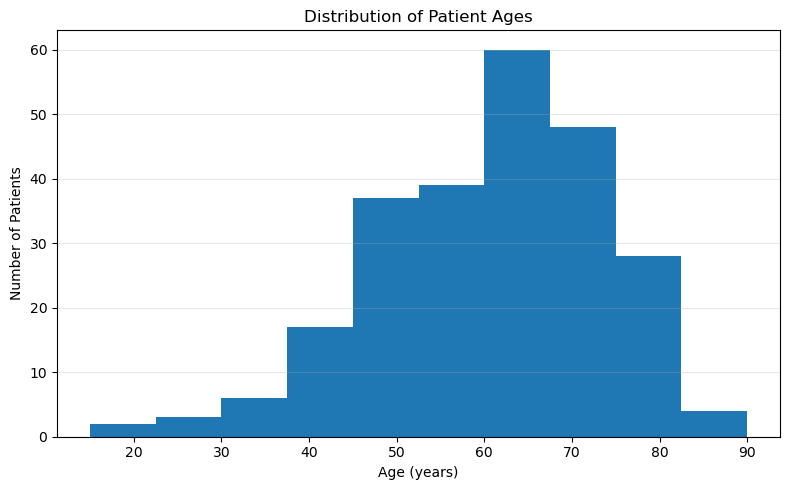

In [236]:
plt.figure(figsize=(8,5)) # gives the graph a consistent, deliberate size.

plt.hist(clean_od['Age'].dropna(), bins=10)
plt.title('Distribution of Patient Ages')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')


plt.grid(axis='y', alpha=0.3) # adds horizontal reference lines so it's easier to estimate the number of patients in each bin.

plt.tight_layout() # adjust the spacing so the plots, titles and labels don't overlap.
plt.show()

In [121]:
clean_od['Age'].skew()

np.float64(-0.47918079855326995)



The distribution of patient ages shows that the dataset contains a broad range of ages, from 15 to 90 years. Most patients are concentrated around the middle-to-older adult age range.

The age distribution has a slight negative skew (skewness ≈ -0.48), indicating a somewhat longer tail toward the younger ages.

### Pneumatic IOP Distribution

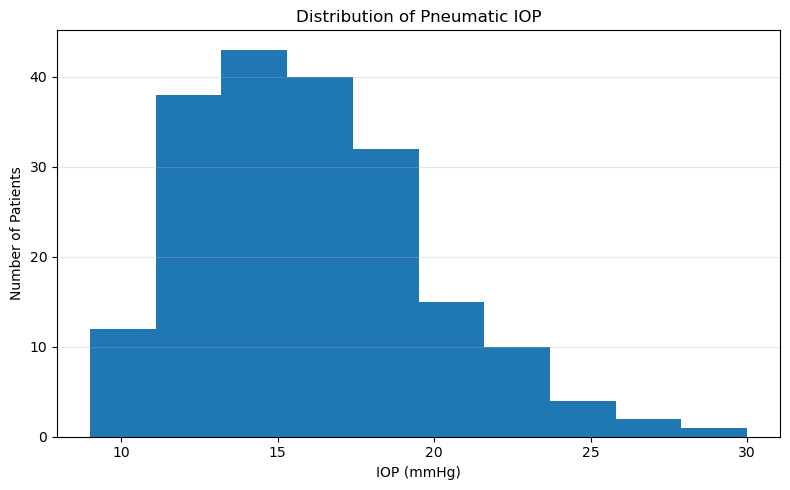

In [237]:
plt.figure(figsize=(8,5))

plt.hist(clean_od['Pneumatic'].dropna(), bins=10)
plt.title('Distribution of Pneumatic IOP')
plt.xlabel('IOP (mmHg)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [202]:
clean_od['Pneumatic'].skew()

np.float64(0.6991531029993697)



Pneumatic IOP had a mean of approximately 16.2 mmHg and a standard deviation of 3.7 mmHg. The median was 16 mmHg, while the observed values ranged from 9 to 30 mmHg.

The distribution shows a moderate positive skew (skewness ≈ 0.70), indicating a longer tail toward higher IOP values.

### Central Corneal Thickness (Pachymetry) Distribution

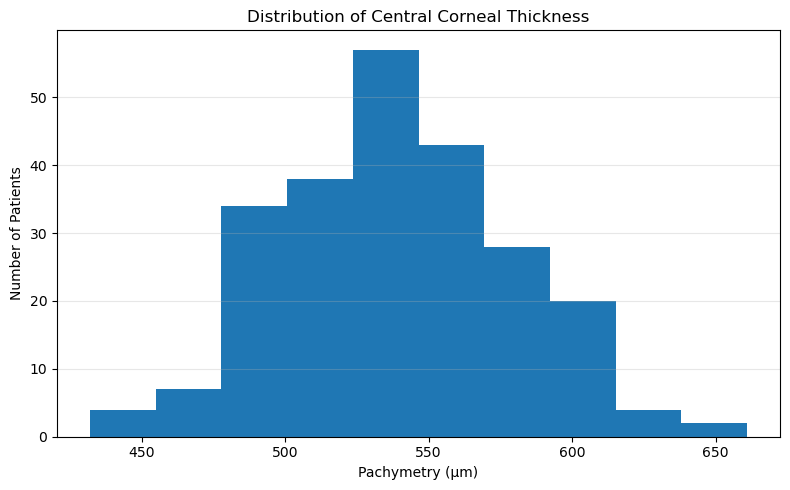

In [238]:
plt.figure(figsize=(8,5))

plt.hist(clean_od['Pachymetry'].dropna(), bins=10)
plt.title('Distribution of Central Corneal Thickness')
plt.xlabel('Pachymetry (µm)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [203]:
clean_od['Pachymetry'].skew()

np.float64(0.17552035854868578)



Pachymetry measurements ranged from 432 to 661 µm, with a mean of approximately 538.6 µm and a standard deviation of 41.0 µm.

The distribution has a slight positive skew (skewness ≈ 0.18), indicating that the measurements are relatively close to symmetric, with a small tendency toward higher values.

### Axial Length Distribution

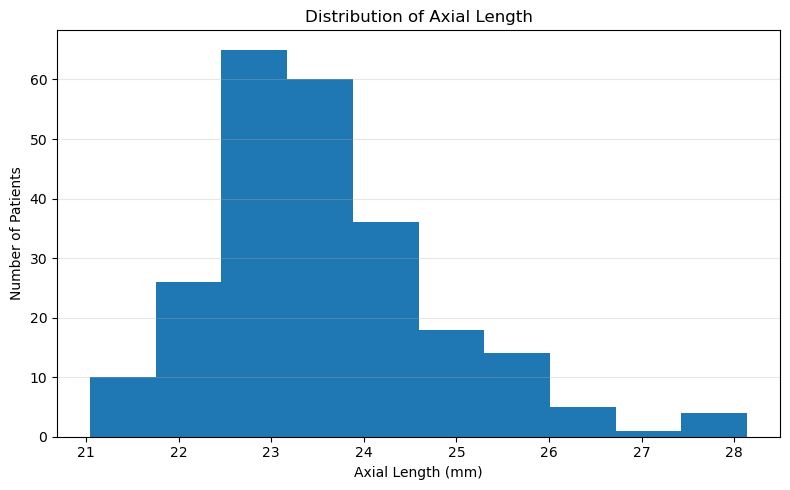

In [239]:
plt.figure(figsize=(8,5))

plt.hist(clean_od['Axial_Length'].dropna(), bins=10)
plt.title('Distribution of Axial Length')
plt.xlabel('Axial Length (mm)')
plt.ylabel('Number of Patients')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
clean_od['Axial_Length'].skew()

np.float64(0.9507286482219935)



Axial length ranged from 21.04 to 28.14 mm, with a mean of approximately 23.6 mm and a standard deviation of 1.24 mm.

The distribution has a positive skew (skewness ≈ 0.95), indicating a longer tail toward higher axial-length values.

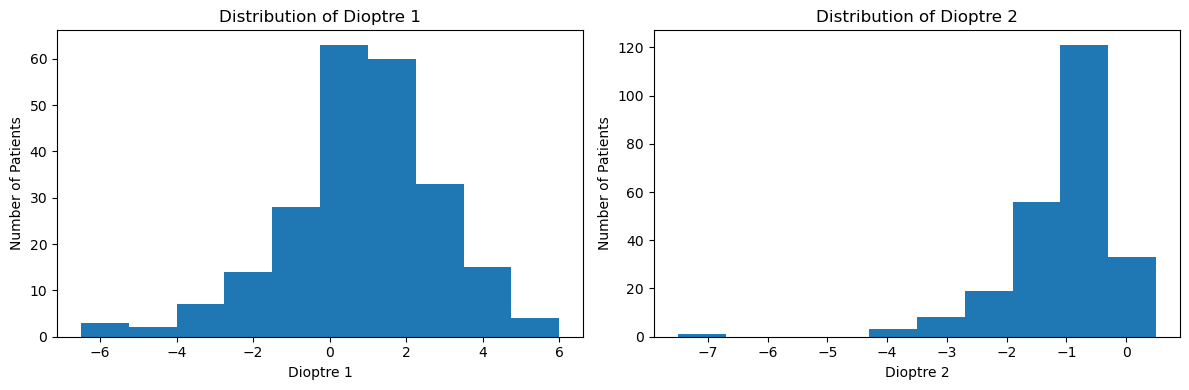

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clean_od['dioptre_1'].dropna(), bins=10)
axes[0].set_title('Distribution of Dioptre 1')
axes[0].set_xlabel('Dioptre 1')
axes[0].set_ylabel('Number of Patients')

axes[1].hist(clean_od['dioptre_2'].dropna(), bins=10)
axes[1].set_title('Distribution of Dioptre 2')
axes[1].set_xlabel('Dioptre 2')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

#Explaination of this code
#plt.subplots() as saying:    "Matplotlib, give me an area where I can put multiple plots."
#plt.subplots(1, 2):          1 row 2 columns
#fig:                         represents the whole figure, the entire area containing the plots
#axes:                        represents the individual plotting areas. axes[0] (left plot), axes[1] (right plot)
#figsize=(12, 4):             controls size of the whole figure. 12 units wide x 4 units tall. can be adjusted 
#axes[0].hist:                equivalent to plt.hist. The one with [0] is for plot 1. with [1] is for plot 2

#axes[0].set_title()     same as    plt.title()
#axes[0].set_xlabel()    same as    plt.xlabel()
#axes[0].set_ylabel()    same as    plt.ylabel()

#plt.tight_layout()          This tells Matplotlib: "Adjust the spacing so the plots, titles and labels don't overlap." 

## Percentiles and Potential Outliers

Percentiles were used to understand how the clinical measurements are distributed across the dataset. The interquartile range (IQR) was used to identify observations that may be unusually high or low compared with the middle 50% of the observations.

In [139]:
Q1 = clean_od['Pneumatic'].quantile(0.25)
Q3 = clean_od['Pneumatic'].quantile(0.75)
IQR = Q3 -Q1

lower_limit = Q1 - 1.5 * (IQR)
upper_limit = Q3 + 1.5 * (IQR)

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower limit:', lower_limit)
print('Upper limit', upper_limit)

Q1: 13.0
Q3: 18.0
IQR: 5.0
Lower limit: 5.5
Upper limit 25.5


The IQR rule says observations below 5.5 mmHg or above 25.5 mmHg are potential outliers.

### Potential IOP Outliers

Using the IQR method, Pneumatic IOP values above 25.5 mmHg were identified as potential high-value outliers.

These observations are not automatically considered errors. They may represent genuine clinical variation and should therefore be retained unless there is evidence that the measurements are incorrect.

In [171]:
potential_outliers = clean_od[clean_od['Pneumatic'] > upper_limit][['ID', 'Pneumatic']]

potential_outliers

,ID,Pneumatic
51,#066,30.0
138,#180,26.0
167,#210,26.0


<function matplotlib.pyplot.show(close=None, block=None)>

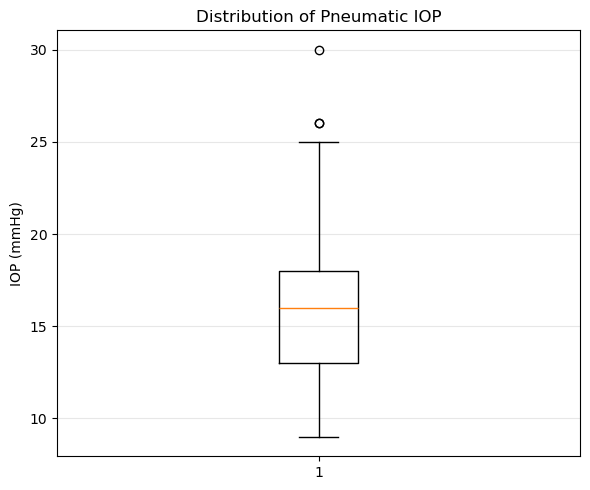

In [242]:
plt.figure(figsize=(6, 5))

plt.boxplot(clean_od['Pneumatic'].dropna())
plt.title('Distribution of Pneumatic IOP')
plt.ylabel('IOP (mmHg)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show

In [143]:
#This gives us the number of Pneumatic IOP measurements above the IQR upper limit.
#The parentheses are simply grouping the expression before we call .sum() on its result.

(clean_od['Pneumatic'] > upper_limit).sum()    

np.int64(3)

In [144]:
clean_od[numeric_cols].skew()

Age            -0.479181
dioptre_1      -0.553512
dioptre_2      -2.650826
astigmatism    -0.030396
Pneumatic       0.699153
Perkins         0.644450
Pachymetry      0.175520
Axial_Length    0.950729
VF_MD          -2.123654
dtype: float64

## Relationships Between Clinical Variables

Correlation analysis was used to examine the strength and direction of linear relationships between the numerical clinical variables.

A correlation coefficient ranges from -1 to +1. Values closer to +1 indicate a stronger positive relationship, while values closer to -1 indicate a stronger negative relationship. Values close to 0 indicate little or no linear relationship.

Correlation does not imply causation.

In [150]:
correlation_matrix = clean_od[numeric_cols].corr()
correlation_matrix

,Age,dioptre_1,dioptre_2,astigmatism,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
Age,1.000000,0.312348,-0.307716,-0.023258,0.024046,0.025222,0.038545,-0.193329,-0.327663
dioptre_1,0.312348,1.000000,-0.199392,0.035114,0.020388,0.008850,0.014289,-0.471837,-0.083268
dioptre_2,-0.307716,-0.199392,1.000000,-0.034114,0.005749,-0.223574,-0.067568,0.065755,0.151081
astigmatism,-0.023258,0.035114,-0.034114,1.000000,-0.008675,-0.018004,-0.043569,-0.011351,-0.060086
Pneumatic,0.024046,0.020388,0.005749,-0.008675,1.000000,0.551652,0.511354,0.027418,0.414103
Perkins,0.025222,0.008850,-0.223574,-0.018004,0.551652,1.000000,0.282463,-0.082910,0.085944
Pachymetry,0.038545,0.014289,-0.067568,-0.043569,0.511354,0.282463,1.000000,-0.025336,0.193275
Axial_Length,-0.193329,-0.471837,0.065755,-0.011351,0.027418,-0.082910,-0.025336,1.000000,0.116112
VF_MD,-0.327663,-0.083268,0.151081,-0.060086,0.414103,0.085944,0.193275,0.116112,1.000000


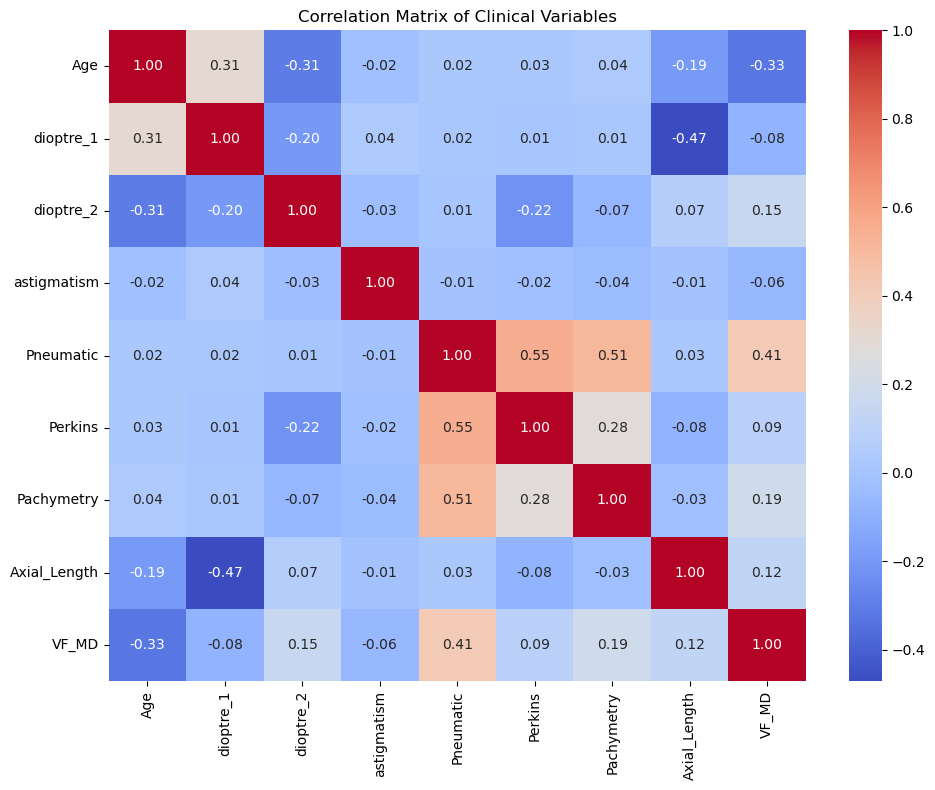

In [235]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Clinical Variables')

plt.tight_layout()
plt.show()

### Key Correlation Findings

Several relationships stood out in the correlation matrix.

- **Pneumatic IOP and Perkins IOP** showed a moderate positive correlation (r ≈ 0.55), indicating that higher values measured with one method tended to be associated with higher values measured with the other.

- **Pneumatic IOP and Pachymetry** showed a moderate positive correlation (r ≈ 0.51), indicating a tendency for higher pachymetry measurements to be associated with higher Pneumatic IOP values.

- **Dioptre 1 and Axial Length** showed a moderate negative correlation (r ≈ -0.47), indicating an inverse linear relationship between the two measurements.

- **Age and VF_MD** showed a moderate negative correlation (r ≈ -0.33). However, VF_MD had substantial missing data, with only 82 available observations, so this relationship should be interpreted cautiously.

- **Age and Pneumatic IOP** showed almost no linear correlation (r ≈ 0.02), suggesting little evidence of a linear relationship between age and Pneumatic IOP in this dataset.

These correlations describe associations within the dataset and do not establish causal relationships.

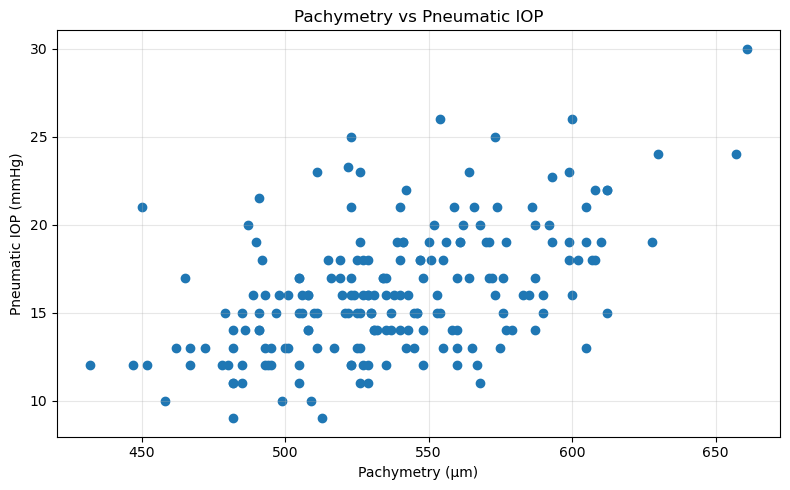

In [246]:
plt.figure(figsize=(8,5))

plt.scatter(clean_od['Pachymetry'], clean_od['Pneumatic'])
plt.title('Pachymetry vs Pneumatic IOP')
plt.xlabel('Pachymetry (µm)')
plt.ylabel('Pneumatic IOP (mmHg)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot shows a general upward tendency between pachymetry and Pneumatic IOP, consistent with the moderate positive correlation (r ≈ 0.51) observed in the correlation matrix.

However, the points show considerable variation around this overall pattern, indicating that pachymetry does not perfectly predict Pneumatic IOP.

This relationship represents an association rather than evidence of causation.

## Covariance Analysis

In [161]:
covariance_matrix = clean_od[numeric_cols].cov()
covariance_matrix

,Age,dioptre_1,dioptre_2,astigmatism,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
Age,171.090602,8.152393,-3.301158,-12.328504,1.138480,1.305556,20.141618,-3.090718,-26.637687
dioptre_1,8.152393,4.166648,-0.342813,2.984070,0.144723,0.080006,1.183085,-1.221025,-1.091730
dioptre_2,-3.301158,-0.342813,0.725827,-1.222537,0.015068,-0.697517,-2.373377,0.069516,0.776347
astigmatism,-12.328504,2.984070,-1.222537,1765.458839,-1.369710,-2.534306,-75.104096,-0.599032,-13.415598
Pneumatic,1.138480,0.144723,0.015068,-1.369710,13.424958,8.652632,78.603629,0.114976,12.150160
Perkins,1.305556,0.080006,-0.697517,-2.534306,8.652632,16.594990,44.380218,-0.536186,2.159675
Pachymetry,20.141618,1.183085,-2.373377,-75.104096,78.603629,44.380218,1681.567511,-1.281453,46.503314
Axial_Length,-3.090718,-1.221025,0.069516,-0.599032,0.114976,-0.536186,-1.281453,1.549440,1.060760
VF_MD,-26.637687,-1.091730,0.776347,-13.415598,12.150160,2.159675,46.503314,1.060760,37.718161



Covariance was used to examine how two numerical variables vary together.

A positive covariance indicates that two variables tend to increase or decrease together, while a negative covariance indicates that one variable tends to increase as the other decreases.

Unlike correlation, covariance is dependent on the units and scale of the variables, so its magnitude is not directly comparable across different pairs of variables.

In [195]:
covariance_matrix.loc['Pneumatic', 'Pachymetry']

np.float64(78.6036289900576)

The covariance between Pneumatic IOP and Pachymetry was approximately 78.6. The positive value indicates that the two variables tend to vary in the same direction.

However, the magnitude of covariance cannot be interpreted on its own because covariance depends on the units and scale of the variables. The correlation coefficient is therefore more useful for comparing the strength of relationships.

## Methods

The analysis uses exploratory statistical techniques to examine the clinical data, including:

- Descriptive statistics: mean, median, mode, variance, and standard deviation
- Distribution analysis using histograms
- Skewness to assess the shape of numerical distributions
- Percentiles and interquartile range (IQR) to describe the spread of observations and identify potential outliers
- Boxplots for visualizing the distribution and potential outliers of Pneumatic IOP
- Covariance analysis to examine how numerical variables vary together
- Pearson correlation analysis to examine the strength and direction of linear relationships
- Scatter plots to visually investigate selected relationships between clinical variables

## Key Findings

The exploratory analysis of the PAPILA clinical dataset revealed several notable characteristics:

- The dataset contained **244 patient records** after cleaning, with clinical measurements showing varying levels of completeness.

- Patient age had a mean of approximately **60.6 years** and a standard deviation of **13.1 years**, with a slight negative skew.

- Pneumatic IOP had a mean of approximately **16.2 mmHg** and a standard deviation of **3.7 mmHg**. Its distribution showed moderate positive skewness.

- The middle 50% of Pneumatic IOP measurements fell between **13 and 18 mmHg**, giving an interquartile range of **5 mmHg**. Values above **25.5 mmHg** were identified as potential high-value outliers using the IQR method.

- Pachymetry had a mean of approximately **538.6 µm**, while axial length had a mean of approximately **23.6 mm**.

- A moderate positive correlation was observed between **Pneumatic IOP and Pachymetry (r ≈ 0.51)**.

- **Pneumatic IOP and Perkins IOP** also showed a moderate positive correlation (**r ≈ 0.55**).

- **Dioptre 1 and Axial Length** showed a moderate negative correlation (**r ≈ -0.47**).

- Age showed little linear correlation with Pneumatic IOP (**r ≈ 0.02**), while the relationship between Age and VF_MD was moderately negative (**r ≈ -0.33**). The latter should be interpreted cautiously because VF_MD had only **82 available observations**.

Overall, the analysis demonstrates how descriptive statistics, distributions, percentiles, covariance, and correlation can be used together to explore clinical data and identify patterns that warrant further investigation.

## Conclusion

This project applied fundamental statistical and data-visualization techniques to clinical eye-health data from the PAPILA ophthalmology dataset.

Descriptive statistics were used to summarize the central tendency and variability of the clinical measurements, while histograms and boxplots were used to examine distributions and identify potential outliers.

Percentiles and the interquartile range provided additional insight into the distribution of Pneumatic IOP. Covariance and correlation analysis were then used to investigate relationships between clinical variables, with the strongest relationships visualized using a scatter plot.

The analysis demonstrates how exploratory data analysis can be used to understand the structure and characteristics of clinical data before applying more advanced statistical or machine-learning methods.

This project provides a foundation for further investigation of ophthalmic data using more advanced statistical analysis and, eventually, machine-learning techniques.
